# Research Question 2
## Can a machine learning model accurately predict the average and peak RAM usage of a training run for a specific Unity environment?

In [41]:
# all the imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate

from sklearn.linear_model import LinearRegression, MultiTaskLasso, QuantileRegressor, RANSACRegressor, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

## Data Loading and cleaning

In [27]:
static_df = pd.read_csv("static.csv")
summary_df = pd.read_csv("summary.csv")

# system ram was in bytes for some reason?
static_df["system_ram_mb"]= static_df["system_ram_gb"] / (1024 * 1024)
static_df = static_df.drop(columns=["system_ram_gb"])

# Since macs dont have gpu memory, I will use the system ram as gpu ram
static_df["GPU_ram_mb"] = static_df["GPU_ram_mb"].fillna(
    static_df["system_ram_mb"]
)

# some columns were all NaNs, so basically useless 
all_nan_cols = static_df.columns[static_df.isna().all()]
print("Dropping all-NaN columns:", list(all_nan_cols))
static_df = static_df.drop(columns=all_nan_cols)
static_df = static_df.drop(columns=['reward_extrinsic_gamma', 'reward_extrinsic_strength'])

# after that there were still some rows without some fields, but less than 1%, so I'll drop for now
static_df = static_df.dropna()
summary_df = summary_df.dropna()

df = static_df.merge(
    summary_df[["RunID", "mean_ram_used_mb", "max_ram_used_mb"]],
    on="RunID",
    how="inner"
)

print(static_df.shape)
print(static_df.head)

Dropping all-NaN columns: ['cuda_version']
(6783, 25)
<bound method NDFrame.head of                 RunID     os       cpu  physical_cores  \
0     20251122-222059  macOS  Apple M2               8   
1     20251122-230218  macOS  Apple M2               8   
2     20251122-230332  macOS  Apple M2               8   
3     20251122-231007  macOS  Apple M2               8   
4     20251122-231737  macOS  Apple M2               8   
...               ...    ...       ...             ...   
6932  20260117-224246  macOS  Apple M2               8   
6933  20260118-021007  macOS  Apple M2               8   
6934  20260118-032354  macOS  Apple M2               8   
6935  20260118-083735  macOS  Apple M2               8   
6936         run_id_1  macOS  Apple M2               8   

                          gpu   GPU_ram_mb training_type          game_name  \
0     Chipset Model: Apple M2  8191.995621           ppo             3DBall   
1     Chipset Model: Apple M2  8191.995621           ppo     

In [28]:
targets = [
    "mean_ram_used_mb",
    "max_ram_used_mb"
]

In [29]:
drop_columns = ["summary_freq", "RunID"]
X = df[static_df.columns.drop(drop_columns)]
y_mean = df["mean_ram_used_mb"]
y_max = df["max_ram_used_mb"]

In [30]:
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns
numeric_cols = X.select_dtypes(exclude=["object", "bool"]).columns

### Functions that can be used for both mean and max ram (essentially the same pipeline)

In [124]:
def cross_validate_models(model_list, preprocessor, x, y):
    scoring = {
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    results = []
    for model_name, regressor in model_list.items():
        pipeline = Pipeline(
            steps=[
                ("preprocess", preprocessor),
                ("model", regressor)
            ]
        )
        scores = cross_validate(pipeline,X,y,cv=cv,scoring=scoring,n_jobs=-1)
        results.append({
            "Model": model_name,
            "MAE (MB)": -scores["test_mae"].mean(),
            "R²": scores["test_r2"].mean()
        })
    return results

def train_models(model_list, preprocessor, X_train, y_train, X_test, y_test):
    results = []
    for model_name, regressor in model_list.items():
        pipeline = Pipeline(
            steps=[
                ("preprocess", preprocessor),
                ("model", regressor)
            ]
        )
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)           
        results.append({
            "Model": model_name,
            "MAE (MB)": mean_absolute_error(y_test, y_pred),
            "R²": r2_score(y_test, y_pred)
        })
        plt.figure(figsize=(7, 7))
        sns.scatterplot(
            x=y_test,
            y=y_pred,
            alpha=0.7
        )
        plt.title(f"Model: {model_name}")
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        
        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            "--",
            color="red",
        )
    return results

def display_results(results):
    results_df = pd.DataFrame(results).sort_values("MAE (MB)")    
    print(results_df)

In [125]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

In [136]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    ),
    "RANSACRegressor": RANSACRegressor(),
}

### Mean RAM used

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y_mean, test_size=0.2, random_state=42)

              Model     MAE (MB)        R²
2  GradientBoosting  1223.939752  0.896547
1      RandomForest  1228.006790  0.897968
0  LinearRegression  1342.589060  0.891391
3   RANSACRegressor  1848.460685  0.675989


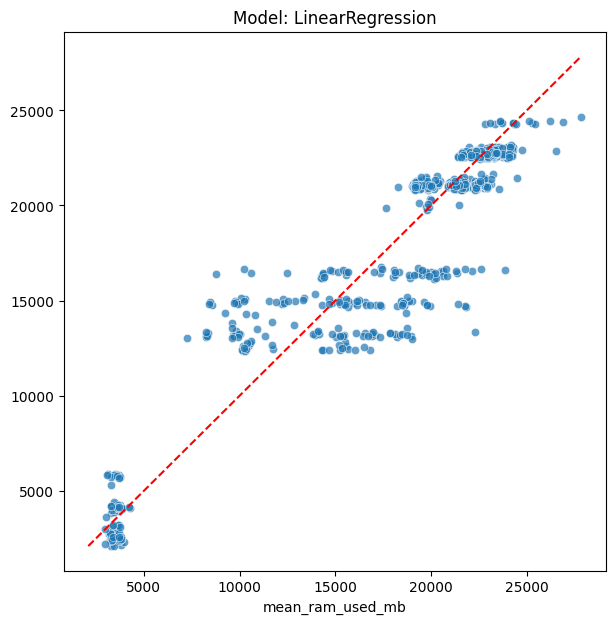

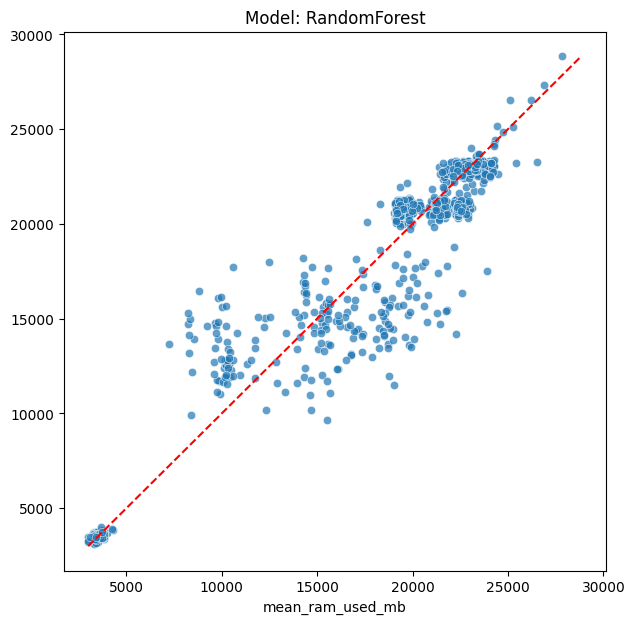

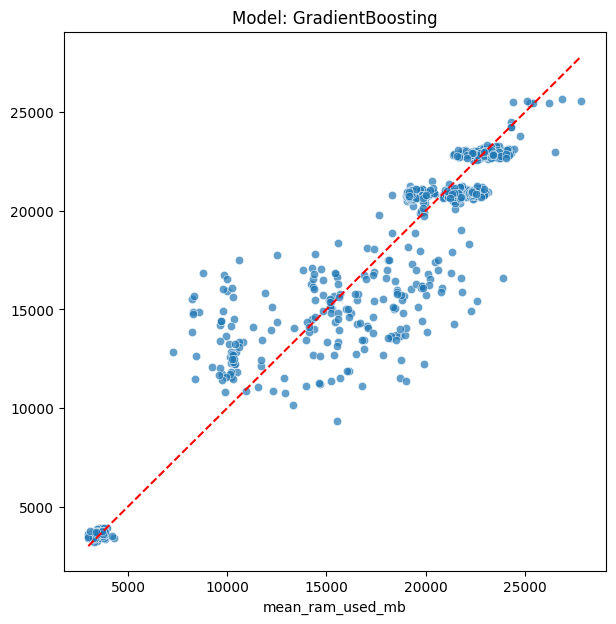

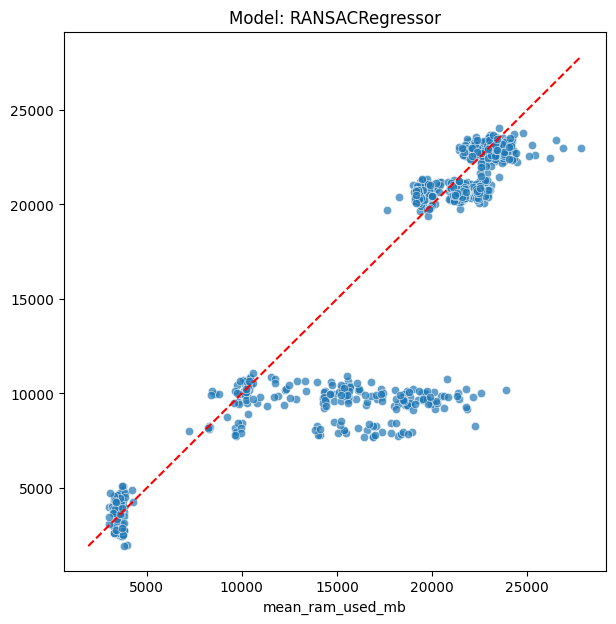

In [134]:
results = train_models(models, preprocessor, X_train, y_train, X_test, y_test)
display_results(results)

In [135]:
results = cross_validate_models(models, preprocessor, X, y_mean)
display_results(results)

              Model     MAE (MB)        R²
1      RandomForest  1177.688593  0.905470
2  GradientBoosting  1179.834213  0.905515
0  LinearRegression  1297.410698  0.896011
3   RANSACRegressor  1429.785589  0.842580


### Max RAM used

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y_max, test_size=0.2, random_state=42)

In [111]:
results = cross_validate_models(models, preprocessor, X, y_max)
display_results(results)

              Model     MAE (MB)        R²
1      RandomForest  1230.000012  0.894346
2  GradientBoosting  1235.473909  0.895400
0  LinearRegression  1367.999805  0.880811
3   RANSACRegressor  1460.276678  0.840167


              Model     MAE (MB)        R²
2  GradientBoosting  1280.633778  0.888760
1      RandomForest  1283.933172  0.885640
0  LinearRegression  1422.407040  0.873427
3   RANSACRegressor  1509.812583  0.833891


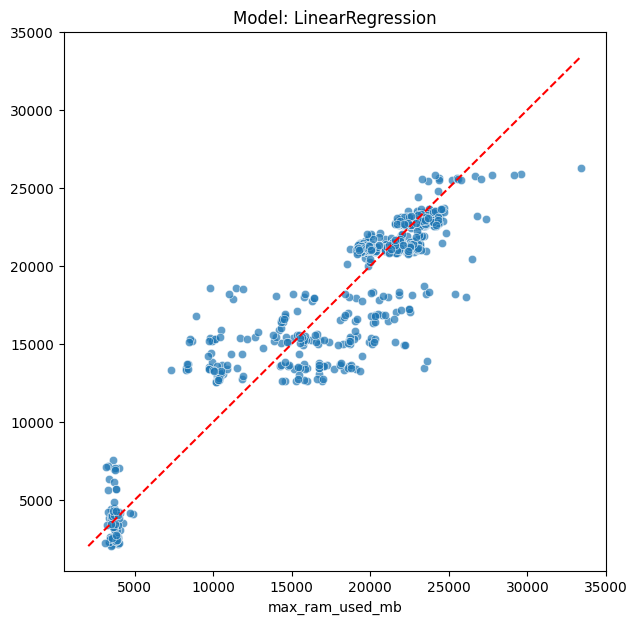

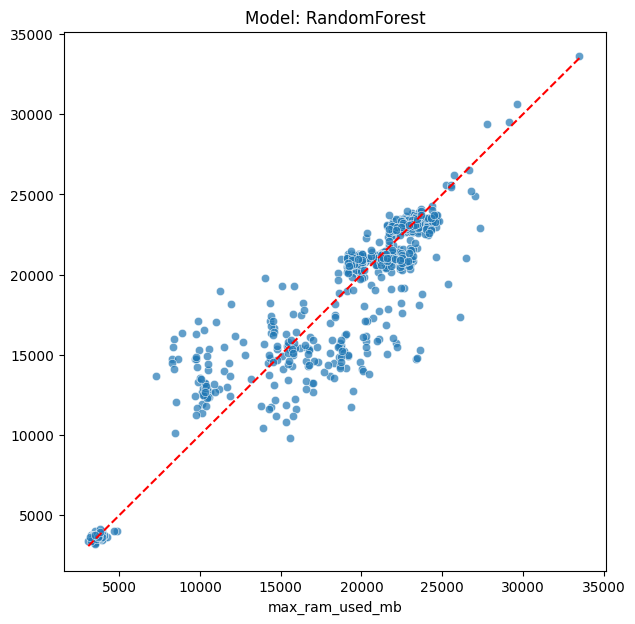

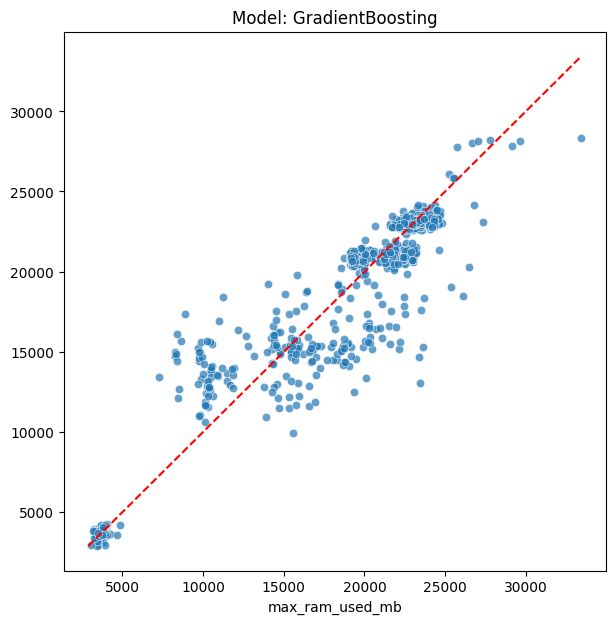

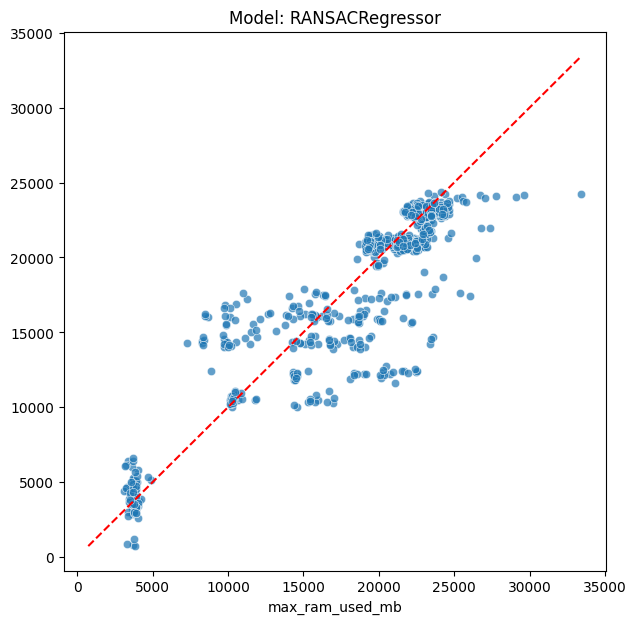

In [112]:
results = train_models(models, preprocessor, X_train, y_train, X_test, y_test)
display_results(results)